#“Proyecto: Análisis estadístico sobre hábitos saludables en jóvenes universitarios”



In [4]:
#DICCIONARIO DE VARIABLES

#edad: Edad del estudiante (años)
#horas_sueno: Promedio de horas de sueño diario
#actividad_fisica: Días de ejercicio por semana
#alimentacion_saludable: Indica si mantiene alimentación saludable
#consumo_cafe: Número de tazas de café diarias
#nivel_estres: Nivel percibido de estrés (1–10)

In [5]:
#Creación de dataset
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

edad = np.random.randint(18, 30, n)

horas_sueno = np.random.normal(loc=6.5, scale=1.2, size=n)
horas_sueno = np.clip(horas_sueno, 4, 9)

actividad_fisica = np.random.binomial(7, 0.4, n)

alimentacion_saludable = np.random.choice(["Sí", "No"], size=n, p=[0.6, 0.4])

consumo_cafe = np.random.poisson(lam=2, size=n)

nivel_estres = np.random.normal(loc=6, scale=1.5, size=n)
nivel_estres = np.clip(nivel_estres, 1, 10)

df = pd.DataFrame({
    "edad": edad,
    "horas_sueno": horas_sueno,
    "actividad_fisica": actividad_fisica,
    "alimentacion_saludable": alimentacion_saludable,
    "consumo_cafe": consumo_cafe,
    "nivel_estres": nivel_estres
})

df.head()

,edad,horas_sueno,actividad_fisica,alimentacion_saludable,consumo_cafe,nivel_estres
0,24,7.043524,2,Sí,3,2.857264
1,21,6.300727,4,Sí,3,6.381261
2,28,6.757927,4,Sí,6,5.611124
3,25,4.073222,6,Sí,3,7.850530
4,22,5.368332,2,No,3,6.973386


In [6]:
df.to_csv("habitos_salud_universitarios.csv", index=False)
df.to_excel("habitos_salud_universitarios.xlsx", index=False)

#LECCIÓN 1 MÉTODO CIENTÍFICO Y ESTADÍSTICA


In [ ]:
#La correspondiente respues al problema de investigación, hipótesis y metodología a utilizar se realizaran en el informe
#así como las tareas, problemas a investigar, hipótesis, variables relevantes, el enfoque y diseño preliminar.

#LECCIÓN 2 – PROBABILIDAD

In [5]:
#Definición del espacio muestral (S):
#Todos los estudiantes de la muestra (n = 200).
#Cada estudiante representa un resultado posible.

#Definición de eventos. Definimos eventos relevantes para el análisis:
#A: El estudiante duerme menos de 6 horas.
#B: El estudiante realiza menos de 2 días de actividad física por semana.
#C: El estudiante consume 3 o más tazas de café al día.

#Calculo de probabilidades.
# Evento A: dormir menos de 6 horas
A = df[df["horas_sueno"] < 6]
P_A = len(A) / len(df)

# Evento B: menos de 2 días de actividad física
B = df[df["actividad_fisica"] < 2]
P_B = len(B) / len(df)

# Evento C: consumo alto de café (>=3)
C = df[df["consumo_cafe"] >= 3]
P_C = len(C) / len(df)

P_A, P_B, P_C

(0.3, 0.175, 0.33)

In [6]:
#Probalidad conjunta
# Intersección A ∩ B
A_inter_B = df[(df["horas_sueno"] < 6) & (df["actividad_fisica"] < 2)]
P_A_inter_B = len(A_inter_B) / len(df)

P_A_inter_B

0.035

In [7]:
#Probabilidad condicional
#P(A∣B)=P(B)P(A∩B)​
P_A_dado_B = P_A_inter_B / P_B
P_A_dado_B

0.20000000000000004

#LECCIÓN 3 – DISTRIBUCIONES

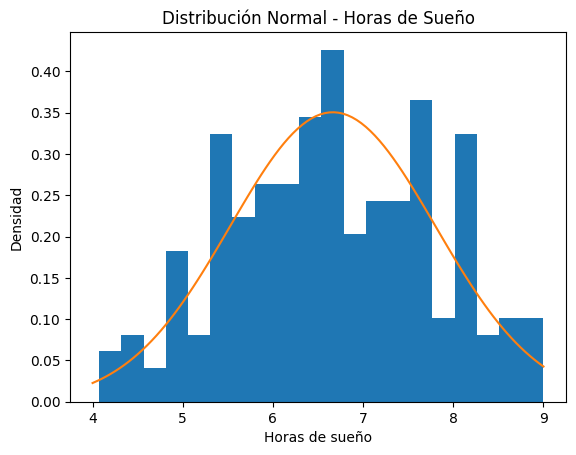

In [8]:
#Identificar, justificar y aplicar distribuciones probabilísticas adecuadas a las variables del estudio.
#Trabajaremos distribución normal, binominal y poisson

#Distribución normal
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Media y desviación
media = df["horas_sueno"].mean()
desv = df["horas_sueno"].std()

# Histograma
plt.hist(df["horas_sueno"], bins=20, density=True)

# Curva normal teórica
x = np.linspace(4, 9, 100)
plt.plot(x, stats.norm.pdf(x, media, desv))

plt.title("Distribución Normal - Horas de Sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Densidad")
plt.show()

In [9]:
#Probabilidad de dormir menos de 6 horas de sueño
stats.norm.cdf(6, media, desv)

np.float64(0.27983180717604494)

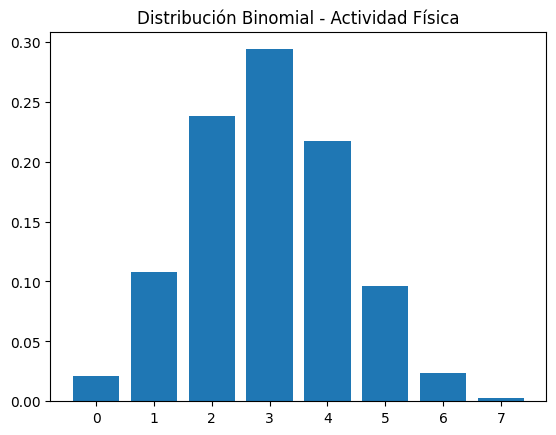

In [11]:
#Distribución Binominal
#La variable actividad_fisica representa número de días con ejercicio (0–7).
#Se puede modelar como binomial porque:Número fijo de ensayos (7 días).
#Cada día puede ser éxito (hizo ejercicio) o fracaso (no hizo).
#Probabilidad constante aproximada.

n = 7
p = df["actividad_fisica"].mean() / 7  # estimación de probabilidad (3 días de ejercicio)

stats.binom.pmf(3, n, p)
x_bin = np.arange(0, 8)
plt.bar(x_bin, stats.binom.pmf(x_bin, n, p))
plt.title("Distribución Binomial - Actividad Física")
plt.show()


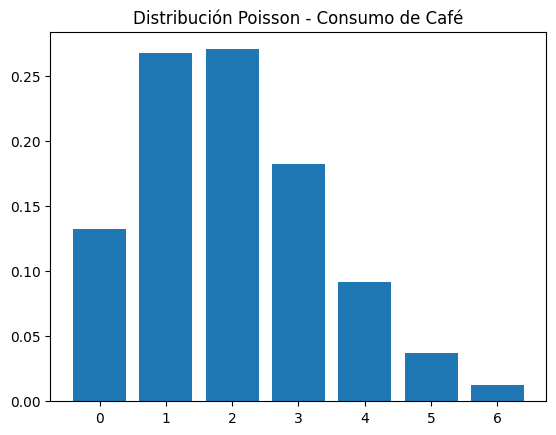

In [14]:
#Distribución Poisson (consumo_cafe)
lambda_ = df["consumo_cafe"].mean()

# Probabilidad de consumir exactamente 2 tazas
prob_2_cafe = stats.poisson.pmf(2, lambda_)
prob_2_cafe
x_pois = np.arange(0, max(df["consumo_cafe"]) + 1)
plt.bar(x_pois, stats.poisson.pmf(x_pois, lambda_))
plt.title("Distribución Poisson - Consumo de Café")
plt.show()
##El consumo de café se modeló mediante una distribución de Poisson con parámetro λ igual a la media muestral.

En esta sección se identificaron y aplicaron distribuciones de probabilidad acordes al tipo de variable analizada.
Las variables continuas fueron modeladas mediante distribución normal, mientras que las discretas fueron ajustadas a distribuciones binomial y Poisson según su naturaleza.
Se calcularon probabilidades teóricas utilizando software estadístico y se graficaron las funciones de distribución correspondientes.

#LECCIÓN 4 – Distribución Muestral y TLC

In [16]:
#Trabajaremos con la variable: horas_sueno
#Generar distribución muestral de la media
#Vamos a:Tomar muchas muestras, Calcular la media de cada muestra,Guardar esas medias,Graficar su distribución

#(codigo principal)
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_muestra = 30        # tamaño muestral
repeticiones = 1000   # número de muestras

medias_muestrales = []

for _ in range(repeticiones):
    muestra = df["horas_sueno"].sample(n=n_muestra, replace=True)
    medias_muestrales.append(muestra.mean())

medias_muestrales = np.array(medias_muestrales)

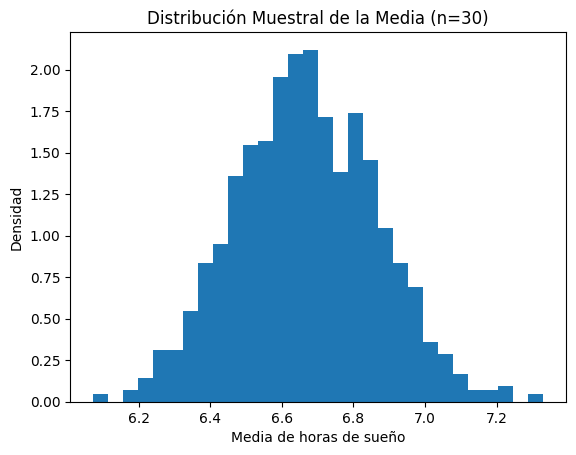

In [17]:
#Grafico de distribución muestral
plt.hist(medias_muestrales, bins=30, density=True)
plt.title("Distribución Muestral de la Media (n=30)")
plt.xlabel("Media de horas de sueño")
plt.ylabel("Densidad")
plt.show()

In [18]:
#Verificar el Teorema de Límite Central
#Ahora comparamos: Media poblacional, Media de las medias, Desviación poblacional, Error estándar
media_poblacional = df["horas_sueno"].mean()
desv_poblacional = df["horas_sueno"].std()

media_muestral_promedio = medias_muestrales.mean()
desv_muestral = medias_muestrales.std()

error_estandar_teorico = desv_poblacional / np.sqrt(n_muestra)

media_poblacional, media_muestral_promedio, desv_muestral, error_estandar_teorico

(np.float64(6.6639166900035205),
 np.float64(6.667042571282673),
 np.float64(0.19751755482404026),
 np.float64(0.20779270096091315))

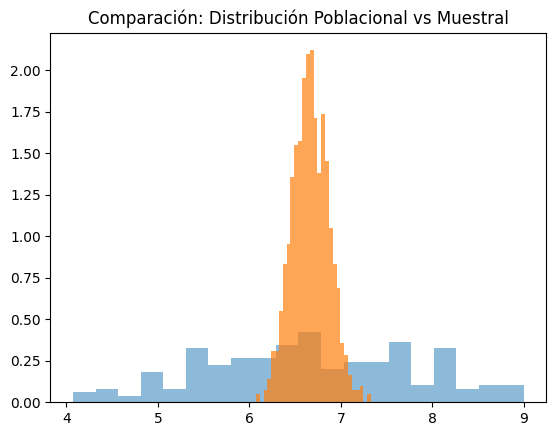

In [19]:
#Comparación entre población vs distribución muestral
plt.hist(df["horas_sueno"], bins=20, density=True, alpha=0.5)
plt.hist(medias_muestrales, bins=30, density=True, alpha=0.7)
plt.title("Comparación: Distribución Poblacional vs Muestral")
plt.show()

In [ ]:
#La muestral es más estrecha
#Tiene menor dispersión

In [20]:
#Analizar efecto del tamaño muestral
#Se probrara con  n = 10, 30 y 50.
def simular_medias(n_muestra):
    medias = []
    for _ in range(1000):
        muestra = df["horas_sueno"].sample(n=n_muestra, replace=True)
        medias.append(muestra.mean())
    return np.array(medias)

medias_10 = simular_medias(10)
medias_30 = simular_medias(30)
medias_50 = simular_medias(50)

print("Desviación n=10:", medias_10.std())
print("Desviación n=30:", medias_30.std())
print("Desviación n=50:", medias_50.std())

Desviación n=10: 0.35634627540686065
Desviación n=30: 0.20208418581032986
Desviación n=50: 0.1582302147966011


In [21]:
#Se lográ apreciar;
#n=10 → mayor dispersión
#n=30 → menor
#n=50 → aún menor
#Esto demuestra que Esto demuestra que: érror estandar= o/(raiz cuadrada de n)

#LECCIÓN 5 – INTERVALOS DE CONFIANZA

Calcular intervalos de confianza para la media de al menos dos
variables
● Interpretar los resultados con distintos niveles de confianza (90%, 95%,
99%)
● Evaluar el impacto del tamaño muestral sobre el ancho del intervalo
● Analizar los resultados y redactar interpretaciones precisas

In [22]:
#Estimar parámetros poblacionales (medias) utilizando intervalos de confianza y analizar su precisión según el nivel de confianza y tamaño muestral.
#Trabajaremos con dos variables: horas_sueno / nivel_estres
#Usaremos t de Student porque: No conocemos σ poblacional.
#Trabajamos con muestra. n = 200 (aunque sea grande, es correcto usar t).

#Codigo general:
import scipy.stats as stats
import numpy as np

def intervalo_confianza(data, confianza=0.95):
    n = len(data)
    media = np.mean(data)
    desv = np.std(data, ddof=1)
    error = stats.t.ppf((1 + confianza) / 2, df=n-1) * (desv / np.sqrt(n))
    return media - error, media + error

In [23]:
#Intervalo para horas_sueno
ic_90 = intervalo_confianza(df["horas_sueno"], 0.90)
ic_95 = intervalo_confianza(df["horas_sueno"], 0.95)
ic_99 = intervalo_confianza(df["horas_sueno"], 0.99)

ic_90, ic_95, ic_99

((np.float64(6.53092341796186), np.float64(6.796909962045181)),
 (np.float64(6.505218030645077), np.float64(6.822615349361964)),
 (np.float64(6.454613315240741), np.float64(6.8732200647663)))

In [24]:
#Intervalo para nivel estres
ic_estres_90 = intervalo_confianza(df["nivel_estres"], 0.90)
ic_estres_95 = intervalo_confianza(df["nivel_estres"], 0.95)
ic_estres_99 = intervalo_confianza(df["nivel_estres"], 0.99)

ic_estres_90, ic_estres_95, ic_estres_99

((np.float64(5.862035207818997), np.float64(6.209098682146824)),
 (np.float64(5.828494409498347), np.float64(6.242639480467474)),
 (np.float64(5.762464571763029), np.float64(6.308669318202792)))

Resultado;
✔ El intervalo 99% es más ancho que el 95%.
✔ El 95% es más ancho que el 90%.
✔ Mayor confianza → mayor margen de error.

In [25]:
#Impacto del espacio muestral
#Se comparará con n = 30.
muestra_30 = df["horas_sueno"].sample(30, random_state=42)
intervalo_confianza(muestra_30, 0.95)

(np.float64(6.075178011656389), np.float64(6.742768025023842))

Resultado; al comparar con n=200, se logra apreciar;
Con n=30 → intervalo más ancho.
Con n=200 → intervalo más estrecho.
Entonces A mayor n → menor error → mayor precisión.

#LECCIÓN 6 – TEST DE HIPÓTESIS

In [ ]:
#Realizaremos pruebas de hipótesis para validar afirmaciones sobre la media poblacional de horas de sueño.
#Trabajaremos con: horas_sueno
#Plantearemos si los estudiantes duermen menos de 7 horas en promedio.

HIPÓTESIS:
H0​ : μ=7
H1​:  μ<7
Es un test unilateral a la izquierda.
Nivel de significancia: α=0.05

Usamos t de Student para una muestra porque:
*No conocemos la desviación poblacional real.
*Estimamos con la muestra.
*Variable cuantitativa continua.

In [26]:
#Calculo estadistico y valor -p
import scipy.stats as stats
import numpy as np

mu_0 = 7
muestra = df["horas_sueno"]

t_stat, p_valor = stats.ttest_1samp(muestra, mu_0)

# Ajustamos porque es prueba unilateral (cola izquierda)
p_valor_unilateral = p_valor / 2

t_stat, p_valor_unilateral

(np.float64(-4.176101330910803), np.float64(2.2170593971711696e-05))

 **Regla de desición**

Si =p-valor<0.05

Rechazamos H₀.

Si = p-valor≥0.05

No hay evidencia suficiente para rechazar H₀.





**Interpretación (modelo listo)**

Si p < 0.05

Se rechaza la hipótesis nula con un nivel de significancia del 5%. Existe evidencia estadística suficiente para afirmar que el promedio de horas de sueño es inferior a 7 horas en la población estudiada.

Si p ≥ 0.05



**Error Tipo I y II**

**Error Tipo I (α = 0.05)**

Rechazar H₀ cuando es verdadera.

Es decir; Concluir que los estudiantes duermen menos de 7 horas cuando en realidad sí duermen 7 horas en promedio.

Probabilidad = 5%.


**Error Tipo II (β)**

No rechazar H₀ cuando es falsa.

Es decir, No detectar que realmente duermen menos de 7 horas.


**Conexión con Intervalos de Confianza**

Si el valor 7 no está dentro del intervalo de confianza al 95%, entonces: El test al 5% rechazará H₀.

#**CONCLUSIÓN HORAS SUEÑO**


Se realizó una prueba t para una muestra con el objetivo de evaluar si el promedio de horas de sueño es inferior a 7 horas.
El estadístico obtenido fue t = -4.176 y el valor-p unilateral fue 0.000022, el cual es significativamente menor que el nivel de significancia α = 0.05.

En consecuencia, se rechaza la hipótesis nula y se concluye que existe evidencia estadística suficiente para afirmar que los estudiantes universitarios duermen menos de 7 horas en promedio.

Estos resultados respaldan la hipótesis de investigación planteada inicialmente y sugieren la necesidad de considerar estrategias orientadas a mejorar los hábitos de sueño en la población estudiada.

#Análisis de Influencia – Correlación

Vamos a evaluar si existe relación lineal entre:

horas_sueno y consumo_cafe

horas_sueno y actividad_fisica

Usaremos correlación de Pearson porque:

Variables cuantitativas

Interesa relación lineal

In [27]:
# Correlación sueño vs café
corr_cafe = df["horas_sueno"].corr(df["consumo_cafe"])

# Correlación sueño vs actividad física
corr_actividad = df["horas_sueno"].corr(df["actividad_fisica"])

corr_cafe, corr_actividad

(np.float64(0.05115875922257801), np.float64(-0.12590578093561916))

Considerando que si:

🔹 Si correlación ≈ 0

No hay relación lineal relevante.

🔹 Si correlación negativa

Más café → menos horas de sueño.

🔹 Si correlación positiva

Más actividad física → más horas de sueño.*texto en cursiva*

In [35]:
from scipy.stats import pearsonr

pearsonr(df["horas_sueno"], df["actividad_fisica"])

PearsonRResult(statistic=np.float64(-0.12590578093561922), pvalue=np.float64(0.07565185369416078))

Resultado

r = -0.1259
p = 0.07565

In [34]:
pearsonr(df["horas_sueno"], df["consumo_cafe"])

PearsonRResult(statistic=np.float64(0.05115875922257802), pvalue=np.float64(0.471875715817112))

Resultado

r = 0.0512
p = 0.4719

**CONCLUSIÓN FINAL**

El test de hipótesis para la media indicó que los estudiantes presentan un promedio de horas de sueño significativamente inferior a las 7 horas recomendadas (p < 0.05).

Sin embargo, el análisis de correlación de Pearson mostró que ni el consumo de café (r = 0.051, p = 0.472) ni la actividad física (r = -0.126, p = 0.076) presentan una asociación estadísticamente significativa con las horas de sueño.

Por lo tanto, aunque se confirma un déficit promedio de sueño en la muestra estudiada, los hábitos analizados no explican de manera significativa esta variabilidad.